# Notebook 3 — TensorFlow Image Augmentation and Classification

This notebook focuses on **image augmentation for classification** using TensorFlow / Keras.

## Topics covered

This notebook includes:

- CIFAR-10 image classification
- baseline CNN without augmentation
- classical Keras preprocessing augmentation
- KerasCV augmentation layers
- short and longer training comparisons
- augmentation pipeline visualization
- TensorBoard and callbacks for augmentation experiments
- compact hyperparameter tuning for augmentation strength
- experiment summary tables and plots

## Main goal

The objective is to compare classification performance **with and without augmentation** and to study how augmentation changes training behavior, validation performance, and generalization.


In [1]:
# TensorFlow is already available in Google Colab.
# Install KerasCV for augmentation layers used later in the notebook.

!pip -q install keras-cv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 35.9 MB/s eta 0:00:00


In [2]:
import os
import random
import shutil
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_cv

from tensorflow import keras
from tensorflow.keras import layers, callbacks

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("KerasCV version:", keras_cv.__version__)


TensorFlow version: 2.19.0
Keras version: 3.13.2
KerasCV version: 0.9.0


## Reproducibility and configuration


In [3]:
SEED = 42

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

AUTO = tf.data.AUTOTUNE
BATCH_SIZE = 128
NUM_CLASSES = 10
IMG_SIZE = (32, 32)
INPUT_SHAPE = (32, 32, 3)

plt.rcParams["figure.figsize"] = (8, 4)


## Dataset: CIFAR-10

CIFAR-10 is a standard image classification dataset with 10 classes and small RGB images.  
It is a good fit for augmentation experiments because:

- the images are diverse,
- the classes are visually meaningful,
- the dataset is lightweight enough for Colab,
- augmentation often improves validation and test performance.


In [4]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# Scale to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Validation split
x_valid = x_train_full[-5000:]
y_valid = y_train_full[-5000:]

x_train = x_train_full[:-5000]
y_train = y_train_full[:-5000]

# Use a moderate subset for faster Colab execution
train_subset = 20000
valid_subset = 3000
test_subset = 3000

x_train = x_train[:train_subset]
y_train = y_train[:train_subset]
x_valid = x_valid[:valid_subset]
y_valid = y_valid[:valid_subset]
x_test_small = x_test[:test_subset]
y_test_small = y_test[:test_subset]

print("Train:", x_train.shape, y_train.shape)
print("Valid:", x_valid.shape, y_valid.shape)
print("Test :", x_test_small.shape, y_test_small.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train: (20000, 32, 32, 3) (20000,)
Valid: (3000, 32, 32, 3) (3000,)
Test : (3000, 32, 32, 3) (3000,)


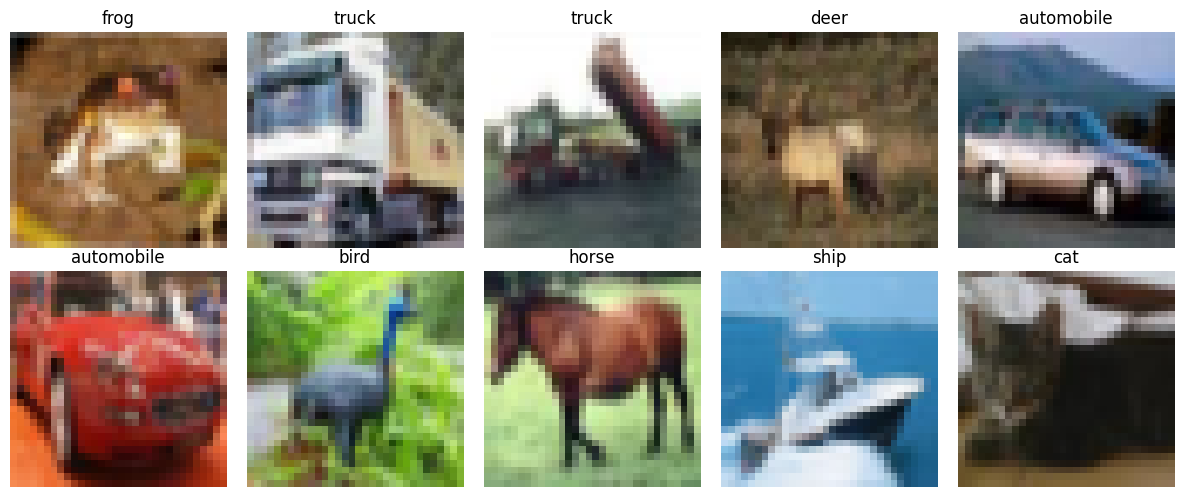

In [5]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()


## Data pipelines

The helper functions below create TensorFlow datasets for:
- the baseline model,
- classical augmentation pipelines,
- KerasCV augmentation pipelines.


In [6]:
def make_ds(x, y, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(len(x), seed=SEED)
    ds = ds.batch(batch_size).prefetch(AUTO)
    return ds

train_ds_plain = make_ds(x_train, y_train, training=True)
valid_ds = make_ds(x_valid, y_valid, training=False)
test_ds = make_ds(x_test_small, y_test_small, training=False)


## Augmentation pipelines

Two augmentation styles are used in this notebook:

### 1. Classical Keras preprocessing augmentation
This includes operations such as:
- random flip,
- random rotation,
- random zoom,
- random contrast.

### 2. KerasCV augmentation
This uses KerasCV layers designed for computer vision workflows, such as:
- RandAugment,
- RandomCutout.

Both pipelines are applied only during training.


In [7]:
classical_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.15),
], name="classical_augmentation")

keras_cv_augmentation = keras.Sequential([
    keras_cv.layers.RandAugment(value_range=(0, 1), magnitude=0.25, augmentations_per_image=2),
    keras_cv.layers.RandomCutout(height_factor=0.2, width_factor=0.2),
], name="keras_cv_augmentation")


In [8]:
def build_augmented_train_ds(x, y, augmentation_layer, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((x, y)).shuffle(len(x), seed=SEED)

    def apply_aug(images, labels):
        images = augmentation_layer(images, training=True)
        images = tf.clip_by_value(images, 0.0, 1.0)
        return images, labels

    ds = ds.batch(batch_size).map(apply_aug, num_parallel_calls=AUTO).prefetch(AUTO)
    return ds

train_ds_classical = build_augmented_train_ds(x_train, y_train, classical_augmentation)
train_ds_kerascv = build_augmented_train_ds(x_train, y_train, keras_cv_augmentation)


## Visualizing the augmentation outputs

The next cells display:
- original images,
- classically augmented images,
- KerasCV-augmented images.

This is useful for verifying that the augmentations are realistic and label-preserving.


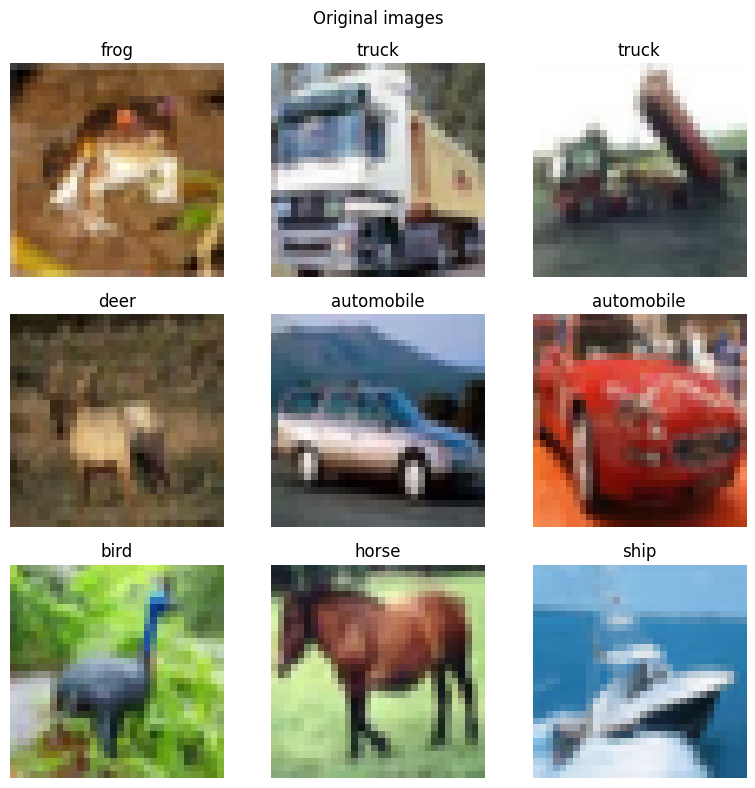

In [9]:
sample_images = x_train[:9]
sample_labels = y_train[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])
    ax.set_title(class_names[sample_labels[i]])
    ax.axis("off")
plt.suptitle("Original images")
plt.tight_layout()
plt.show()


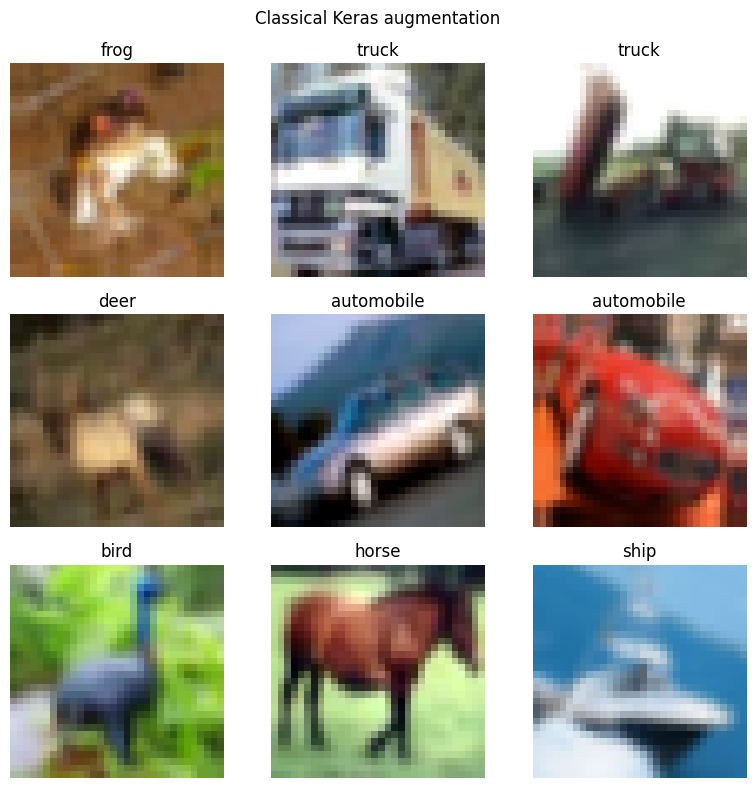

In [10]:
augmented_batch = classical_augmentation(sample_images, training=True)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(tf.clip_by_value(augmented_batch[i], 0.0, 1.0))
    ax.set_title(class_names[sample_labels[i]])
    ax.axis("off")
plt.suptitle("Classical Keras augmentation")
plt.tight_layout()
plt.show()


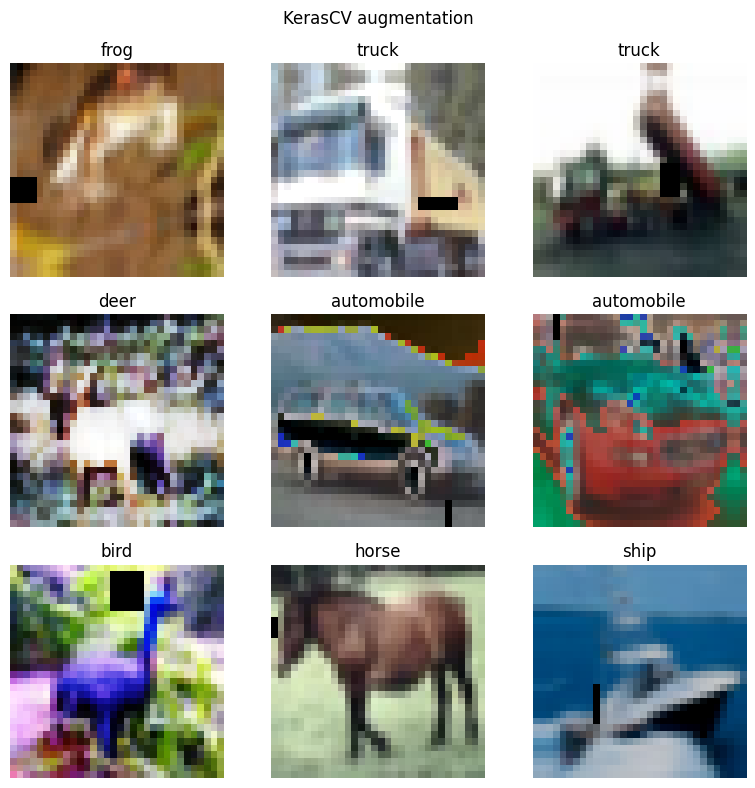

In [11]:
augmented_batch_cv = keras_cv_augmentation(sample_images, training=True)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(tf.clip_by_value(augmented_batch_cv[i], 0.0, 1.0))
    ax.set_title(class_names[sample_labels[i]])
    ax.axis("off")
plt.suptitle("KerasCV augmentation")
plt.tight_layout()
plt.show()


## Model definition

A compact CNN is used across all experiments so that:
- comparisons stay fair,
- the role of augmentation is easier to interpret,
- the notebook remains practical to run in Colab.


In [12]:
def build_cnn_model(drop_rate=0.3):
    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(drop_rate)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(drop_rate)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(drop_rate)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="cifar10_cnn")


## Training helpers


In [13]:
def compile_and_train(model, train_ds, valid_ds, test_ds,
                      epochs=10,
                      learning_rate=1e-3,
                      extra_callbacks=None,
                      verbose=0):
    cb = extra_callbacks or []
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=epochs,
        callbacks=cb,
        verbose=verbose,
    )
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    return history, test_loss, test_acc

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hist[["loss", "val_loss"]].plot(ax=axes[0], title=f"{title} - Loss")
    hist[["accuracy", "val_accuracy"]].plot(ax=axes[1], title=f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()

def summarize_run(name, history, test_acc):
    hist = history.history
    final_train = float(hist["accuracy"][-1])
    final_val = float(hist["val_accuracy"][-1])
    return {
        "experiment": name,
        "best_val_accuracy": float(np.max(hist["val_accuracy"])),
        "final_train_accuracy": final_train,
        "final_val_accuracy": final_val,
        "test_accuracy": float(test_acc),
        "epochs_ran": len(hist["loss"]),
        "overfit_gap": final_train - final_val,
    }

def compare_results(results):
    return pd.DataFrame(results).sort_values("test_accuracy", ascending=False).reset_index(drop=True)


## Baseline model without augmentation

The first experiment trains the CNN on the plain dataset without any training-time augmentation.  
This serves as the reference point for the later augmentation experiments.


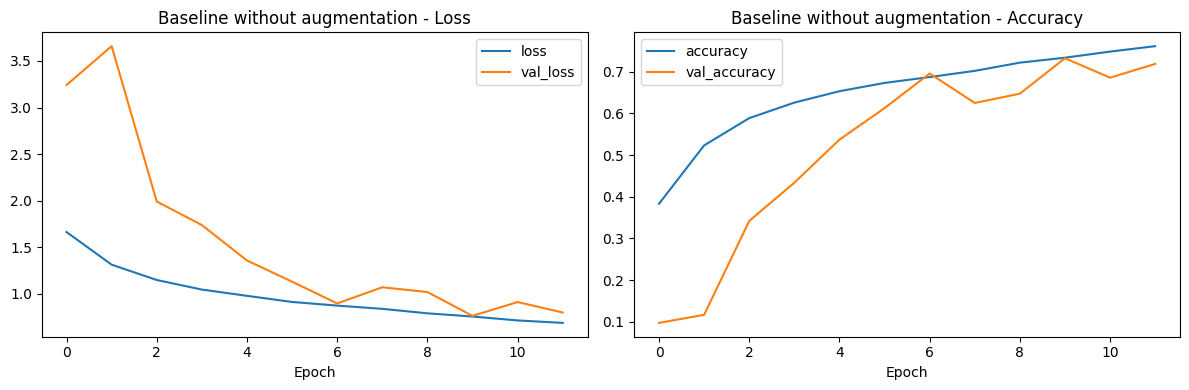

,experiment,best_val_accuracy,final_train_accuracy,final_val_accuracy,test_accuracy,epochs_ran,overfit_gap
0,baseline_no_augmentation,0.732333,0.76125,0.718667,0.706333,12,0.042583


In [14]:
baseline_model = build_cnn_model(drop_rate=0.3)
baseline_history, baseline_test_loss, baseline_test_acc = compile_and_train(
    baseline_model,
    train_ds_plain,
    valid_ds,
    test_ds,
    epochs=12,
    verbose=0
)

plot_history(baseline_history, "Baseline without augmentation")

baseline_results = [
    summarize_run("baseline_no_augmentation", baseline_history, baseline_test_acc)
]
compare_results(baseline_results)


### Interpretation

The baseline model establishes the reference performance before any image augmentation is applied.  
The later comparisons show whether augmentation reduces overfitting and improves validation or test accuracy.


## Classical augmentation experiment

This section trains the same CNN with the classical Keras preprocessing pipeline.

The model architecture is unchanged.  
Only the training images are augmented.


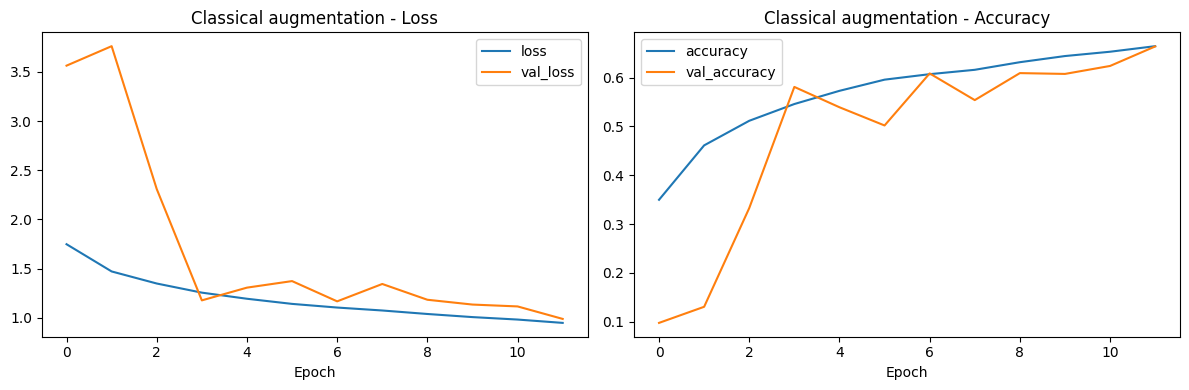

,experiment,best_val_accuracy,final_train_accuracy,final_val_accuracy,test_accuracy,epochs_ran,overfit_gap
0,baseline_no_augmentation,0.732333,0.76125,0.718667,0.706333,12,0.042583
1,classical_augmentation,0.664000,0.66455,0.664000,0.654667,12,0.000550


In [15]:
classical_model = build_cnn_model(drop_rate=0.3)
classical_history, classical_test_loss, classical_test_acc = compile_and_train(
    classical_model,
    train_ds_classical,
    valid_ds,
    test_ds,
    epochs=12,
    verbose=0
)

plot_history(classical_history, "Classical augmentation")

classical_results = [
    summarize_run("baseline_no_augmentation", baseline_history, baseline_test_acc),
    summarize_run("classical_augmentation", classical_history, classical_test_acc),
]
compare_results(classical_results)


### Interpretation

Classical augmentation expands the effective variety of the training set.  
Even when training accuracy becomes slightly lower, validation or test performance can improve because the model sees more diverse examples.


## KerasCV augmentation experiment

This section uses KerasCV layers, which are designed specifically for computer vision training workflows.

The augmentation stack used here includes:
- RandAugment
- RandomCutout


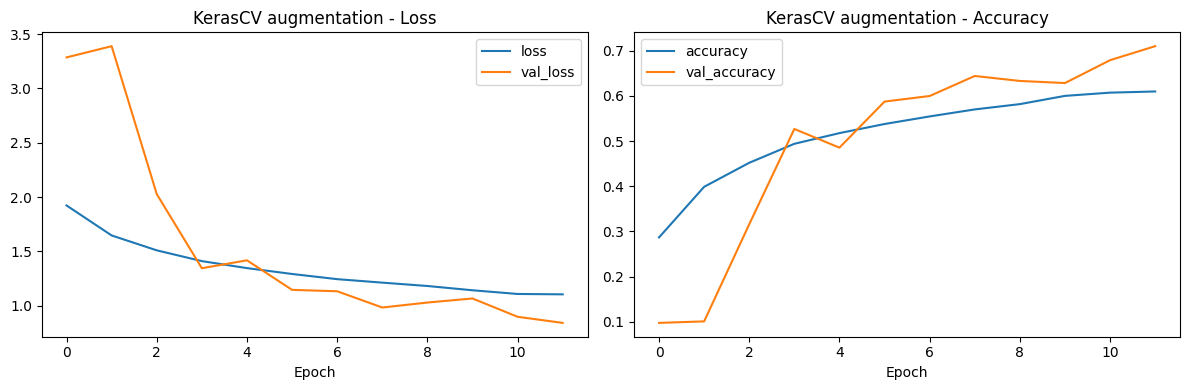

,experiment,best_val_accuracy,final_train_accuracy,final_val_accuracy,test_accuracy,epochs_ran,overfit_gap
0,baseline_no_augmentation,0.732333,0.76125,0.718667,0.706333,12,0.042583
1,kerascv_augmentation,0.710000,0.60970,0.710000,0.695000,12,-0.100300


In [16]:
kerascv_model = build_cnn_model(drop_rate=0.3)
kerascv_history, kerascv_test_loss, kerascv_test_acc = compile_and_train(
    kerascv_model,
    train_ds_kerascv,
    valid_ds,
    test_ds,
    epochs=12,
    verbose=0
)

plot_history(kerascv_history, "KerasCV augmentation")

kerascv_results = [
    summarize_run("baseline_no_augmentation", baseline_history, baseline_test_acc),
    summarize_run("kerascv_augmentation", kerascv_history, kerascv_test_acc),
]
compare_results(kerascv_results)


### Interpretation

KerasCV augmentation typically produces stronger image perturbations than a minimal preprocessing pipeline.  
This can improve robustness, although very strong augmentation may also slow early optimization if the transformed inputs become harder to classify.


## Side-by-side comparison of baseline and augmentation strategies


In [17]:
main_results = [
    summarize_run("baseline_no_augmentation", baseline_history, baseline_test_acc),
    summarize_run("classical_augmentation", classical_history, classical_test_acc),
    summarize_run("kerascv_augmentation", kerascv_history, kerascv_test_acc),
]

main_results_df = compare_results(main_results)
main_results_df


,experiment,best_val_accuracy,final_train_accuracy,final_val_accuracy,test_accuracy,epochs_ran,overfit_gap
0,baseline_no_augmentation,0.732333,0.76125,0.718667,0.706333,12,0.042583
1,kerascv_augmentation,0.710000,0.60970,0.710000,0.695000,12,-0.100300
2,classical_augmentation,0.664000,0.66455,0.664000,0.654667,12,0.000550


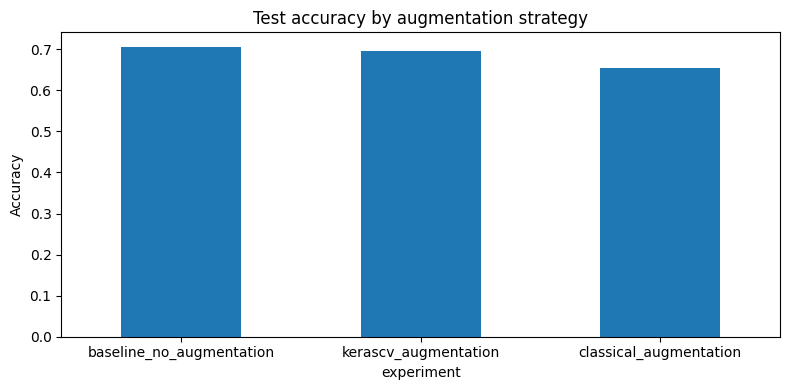

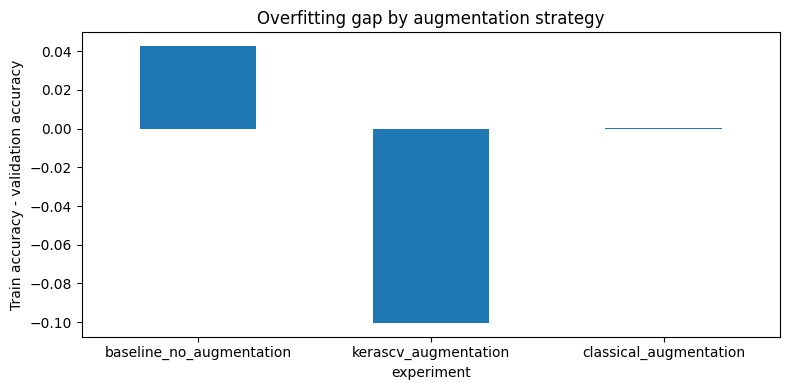

In [18]:
ax = main_results_df.set_index("experiment")["test_accuracy"].plot(kind="bar", rot=0)
ax.set_title("Test accuracy by augmentation strategy")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

ax = main_results_df.set_index("experiment")["overfit_gap"].plot(kind="bar", rot=0)
ax.set_title("Overfitting gap by augmentation strategy")
ax.set_ylabel("Train accuracy - validation accuracy")
plt.tight_layout()
plt.show()


## Short vs longer training comparison

Augmentation can behave differently depending on training duration.

### Main idea
- In shorter training runs, augmentation may look only modestly helpful or even slightly slower to optimize.
- In longer runs, augmentation often becomes more valuable because it reduces memorization and improves generalization.


In [19]:
def run_augmentation_suite(epochs):
    results = []

    baseline = build_cnn_model(drop_rate=0.3)
    base_hist, _, base_test_acc = compile_and_train(
        baseline, train_ds_plain, valid_ds, test_ds, epochs=epochs, verbose=0
    )
    results.append(summarize_run(f"baseline_{epochs}_epochs", base_hist, base_test_acc))

    classical = build_cnn_model(drop_rate=0.3)
    classical_hist, _, classical_test_acc = compile_and_train(
        classical, train_ds_classical, valid_ds, test_ds, epochs=epochs, verbose=0
    )
    results.append(summarize_run(f"classical_aug_{epochs}_epochs", classical_hist, classical_test_acc))

    kerascv = build_cnn_model(drop_rate=0.3)
    kerascv_hist, _, kerascv_test_acc = compile_and_train(
        kerascv, train_ds_kerascv, valid_ds, test_ds, epochs=epochs, verbose=0
    )
    results.append(summarize_run(f"kerascv_aug_{epochs}_epochs", kerascv_hist, kerascv_test_acc))

    return compare_results(results)

short_df = run_augmentation_suite(epochs=6)
long_df = run_augmentation_suite(epochs=15)

print("Short training comparison")
display(short_df)

print("Longer training comparison")
display(long_df)


Short training comparison


,experiment,best_val_accuracy,final_train_accuracy,final_val_accuracy,test_accuracy,epochs_ran,overfit_gap
0,baseline_6_epochs,0.682667,0.67215,0.682667,0.673000,6,-0.010517
1,kerascv_aug_6_epochs,0.628667,0.54650,0.628667,0.619333,6,-0.082167
2,classical_aug_6_epochs,0.586667,0.59080,0.488333,0.488333,6,0.102467


Longer training comparison


,experiment,best_val_accuracy,final_train_accuracy,final_val_accuracy,test_accuracy,epochs_ran,overfit_gap
0,baseline_15_epochs,0.771333,0.78625,0.771333,0.754333,15,0.014917
1,kerascv_aug_15_epochs,0.702000,0.62560,0.702000,0.687333,15,-0.076400
2,classical_aug_15_epochs,0.665000,0.68360,0.638000,0.626333,15,0.045600


In [20]:
comparison_summary = pd.DataFrame([
    {
        "model": "baseline",
        "test_acc_6_epochs": float(short_df.loc[short_df["experiment"].str.contains("baseline"), "test_accuracy"].iloc[0]),
        "test_acc_15_epochs": float(long_df.loc[long_df["experiment"].str.contains("baseline"), "test_accuracy"].iloc[0]),
        "overfit_gap_6_epochs": float(short_df.loc[short_df["experiment"].str.contains("baseline"), "overfit_gap"].iloc[0]),
        "overfit_gap_15_epochs": float(long_df.loc[long_df["experiment"].str.contains("baseline"), "overfit_gap"].iloc[0]),
    },
    {
        "model": "classical_aug",
        "test_acc_6_epochs": float(short_df.loc[short_df["experiment"].str.contains("classical"), "test_accuracy"].iloc[0]),
        "test_acc_15_epochs": float(long_df.loc[long_df["experiment"].str.contains("classical"), "test_accuracy"].iloc[0]),
        "overfit_gap_6_epochs": float(short_df.loc[short_df["experiment"].str.contains("classical"), "overfit_gap"].iloc[0]),
        "overfit_gap_15_epochs": float(long_df.loc[long_df["experiment"].str.contains("classical"), "overfit_gap"].iloc[0]),
    },
    {
        "model": "kerascv_aug",
        "test_acc_6_epochs": float(short_df.loc[short_df["experiment"].str.contains("kerascv"), "test_accuracy"].iloc[0]),
        "test_acc_15_epochs": float(long_df.loc[long_df["experiment"].str.contains("kerascv"), "test_accuracy"].iloc[0]),
        "overfit_gap_6_epochs": float(short_df.loc[short_df["experiment"].str.contains("kerascv"), "overfit_gap"].iloc[0]),
        "overfit_gap_15_epochs": float(long_df.loc[long_df["experiment"].str.contains("kerascv"), "overfit_gap"].iloc[0]),
    },
])

comparison_summary


,model,test_acc_6_epochs,test_acc_15_epochs,overfit_gap_6_epochs,overfit_gap_15_epochs
0,baseline,0.673000,0.754333,-0.010517,0.014917
1,classical_aug,0.488333,0.626333,0.102467,0.045600
2,kerascv_aug,0.619333,0.687333,-0.082167,-0.076400


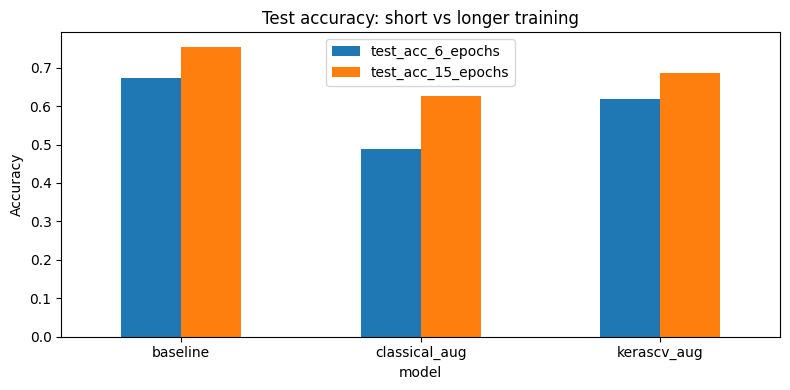

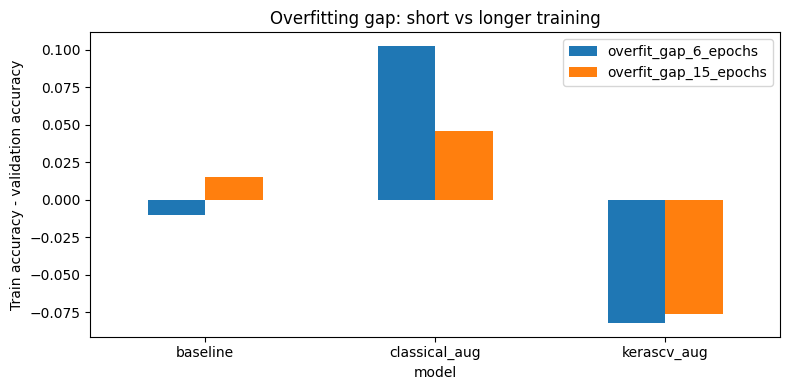

In [21]:
ax = comparison_summary.set_index("model")[["test_acc_6_epochs", "test_acc_15_epochs"]].plot(kind="bar", rot=0)
ax.set_title("Test accuracy: short vs longer training")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

ax = comparison_summary.set_index("model")[["overfit_gap_6_epochs", "overfit_gap_15_epochs"]].plot(kind="bar", rot=0)
ax.set_title("Overfitting gap: short vs longer training")
ax.set_ylabel("Train accuracy - validation accuracy")
plt.tight_layout()
plt.show()


### Interpretation

This comparison separates **optimization speed** from **generalization quality**.

A non-augmented model may learn the training set faster in the short run.  
Augmented training is often more challenging because each batch contains more variation.  
Over a longer run, augmentation often becomes more useful by limiting overfitting and improving robustness.


## Callback-driven augmentation experiment with TensorBoard

This section shows a practical training setup using:
- TensorBoard,
- ModelCheckpoint,
- ReduceLROnPlateau,
- EarlyStopping.

The experiment uses the classical augmentation pipeline.


In [22]:
log_dir = os.path.join("logs", "fit", datetime.now().strftime("%Y%m%d-%H%M%S"))
checkpoint_path = "best_cifar10_augmented_model.keras"

tensorboard_cb = callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
checkpoint_cb = callbacks.ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True)
reduce_lr_cb = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
early_stop_cb = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

callback_model = build_cnn_model(drop_rate=0.3)
callback_history, callback_test_loss, callback_test_acc = compile_and_train(
    callback_model,
    train_ds_classical,
    valid_ds,
    test_ds,
    epochs=20,
    extra_callbacks=[tensorboard_cb, checkpoint_cb, reduce_lr_cb, early_stop_cb],
    verbose=0
)

callback_results = [
    summarize_run("baseline_no_augmentation", baseline_history, baseline_test_acc),
    summarize_run("classical_aug_with_callbacks", callback_history, callback_test_acc),
]

print("TensorBoard log directory:", log_dir)
print("Checkpoint saved to:", checkpoint_path)
compare_results(callback_results)


TensorBoard log directory: logs/fit/20260321-193834
Checkpoint saved to: best_cifar10_augmented_model.keras


,experiment,best_val_accuracy,final_train_accuracy,final_val_accuracy,test_accuracy,epochs_ran,overfit_gap
0,baseline_no_augmentation,0.732333,0.76125,0.718667,0.706333,12,0.042583
1,classical_aug_with_callbacks,0.721333,0.71625,0.709333,0.699667,20,0.006917


In [ ]:
# Uncomment these lines in Colab if needed:
%load_ext tensorboard
%tensorboard --logdir logs/fit


### Interpretation

Augmentation is often used together with learning-rate scheduling, early stopping, and model checkpointing.  
These tools make it easier to monitor whether stronger augmentation improves validation behavior over time.


## Compact augmentation hyperparameter search

This section performs a small manual search over augmentation strength.

The goal is not to exhaustively search the full augmentation space.  
The goal is to compare a few plausible settings and observe how augmentation strength affects performance.


In [ ]:
augmentation_search_configs = [
    {"name": "light_aug", "rotation": 0.04, "zoom": 0.08, "contrast": 0.10},
    {"name": "medium_aug", "rotation": 0.08, "zoom": 0.12, "contrast": 0.15},
    {"name": "strong_aug", "rotation": 0.12, "zoom": 0.20, "contrast": 0.20},
]

search_results = []

for cfg in augmentation_search_configs:
    aug_layer = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(cfg["rotation"]),
        layers.RandomZoom(cfg["zoom"]),
        layers.RandomContrast(cfg["contrast"]),
    ])

    train_ds_cfg = build_augmented_train_ds(x_train, y_train, aug_layer)

    model = build_cnn_model(drop_rate=0.3)
    hist, _, test_acc = compile_and_train(
        model, train_ds_cfg, valid_ds, test_ds, epochs=8, verbose=0
    )

    result = summarize_run(cfg["name"], hist, test_acc)
    result.update(cfg)
    search_results.append(result)

augmentation_search_df = pd.DataFrame(search_results).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
augmentation_search_df


In [ ]:
ax = augmentation_search_df.set_index("name")["test_accuracy"].plot(kind="bar", rot=0)
ax.set_title("Test accuracy by augmentation strength")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()


### Interpretation

Augmentation strength should be balanced.  
If augmentation is too weak, it may not add enough variability.  
If it is too strong, the transformed images may become harder to classify and training may become unnecessarily difficult.

This compact search helps identify a practical range rather than assuming that stronger augmentation is always better.


## Sample predictions from the best-performing augmentation setup

The next section runs predictions using one trained augmentation model and visualizes correct and incorrect examples.


In [ ]:
best_model_for_predictions = classical_model

pred_probs = best_model_for_predictions.predict(test_ds, verbose=0)
pred_labels = pred_probs.argmax(axis=1)

sample_idx = np.arange(16)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for ax, idx in zip(axes.flat, sample_idx):
    true_label = y_test_small[idx]
    pred_label = pred_labels[idx]
    ax.imshow(x_test_small[idx])
    ax.set_title(f"T: {class_names[true_label]}\nP: {class_names[pred_label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


### Interpretation

Prediction examples make it easier to inspect where the model succeeds and where it still confuses similar classes such as:
- cat vs dog,
- automobile vs truck,
- deer vs horse.

Even when augmentation improves aggregate metrics, these class-level confusions can remain.


## Final experiment summary


In [ ]:
final_results = [
    summarize_run("baseline_no_augmentation", baseline_history, baseline_test_acc),
    summarize_run("classical_augmentation", classical_history, classical_test_acc),
    summarize_run("kerascv_augmentation", kerascv_history, kerascv_test_acc),
    summarize_run("classical_aug_with_callbacks", callback_history, callback_test_acc),
]

final_results_df = compare_results(final_results)
final_results_df


In [ ]:
ax = final_results_df.set_index("experiment")["test_accuracy"].plot(kind="barh")
ax.set_title("Final test accuracy across augmentation experiments")
ax.set_xlabel("Test accuracy")
plt.tight_layout()
plt.show()


## Key conclusions

This notebook highlights the following ideas:

1. **Image augmentation improves the effective diversity of the training data.**
2. **Lower training accuracy does not necessarily mean worse generalization.**
3. **Classical Keras augmentation and KerasCV augmentation provide two different ways to build image pipelines.**
4. **Augmentation often becomes more valuable as training gets longer and overfitting risk increases.**
5. **Callbacks, TensorBoard, and compact tuning experiments make augmentation workflows easier to monitor and refine.**

## Next step in the project

The next notebook can extend augmentation beyond images to other modalities such as:
- text,
- time series,
- tabular data,
- speech,
- document images,
- video.
